<a href="https://colab.research.google.com/github/ramirezcarlos292/miaad_math_for_ai/blob/main/Optimizacion_de_lote.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [350]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import random

Constantes Problema pequeño:

In [351]:
# n_total: número de ejemplos de entrenamiento
n_total = 10e8

# t_mean: tiempo promedio por iteración (ms)
t_mean = 10

# c: constante positiva del coste computacional(B^2)
c_value = random.uniform(10e-6, 10e-3)
c_value = 10e-6

Definición de Variables simbolicas

In [352]:
N_total, B, t0, c = sp.symbols('N_total B t_0 c')

Definición de ecuaciones

In [353]:
# N(B): Número de iteraciones necesarias
NB = N_total / B
NB

N_total/B

In [354]:
# t(B): Tiempo por iteración (segundos)
tB = t0 + c / N_total * B**3
tB

B**3*c/N_total + t_0

In [355]:
# T(B): Tiempo total de entrenamiento
TB = sp.simplify(NB * tB)
TB

(B**3*c + N_total*t_0)/B

In [356]:
# T(B): Tiempo total de entrenamiento
TB2 = (t0 * N_total / B) + (c * B**2)
TB2

B**2*c + N_total*t_0/B

Sustitución de constantes (para gráficar)

In [357]:
# T(B): Tiempo total de entrenamiento [a mano]
TB2_eval = TB2.subs({N_total: n_total, c: c_value, t0: t_mean})
TB2_eval

1.0e-5*B**2 + 10000000000.0/B

Generar tamaños de lote

#### Evaluar los tamaños de lote

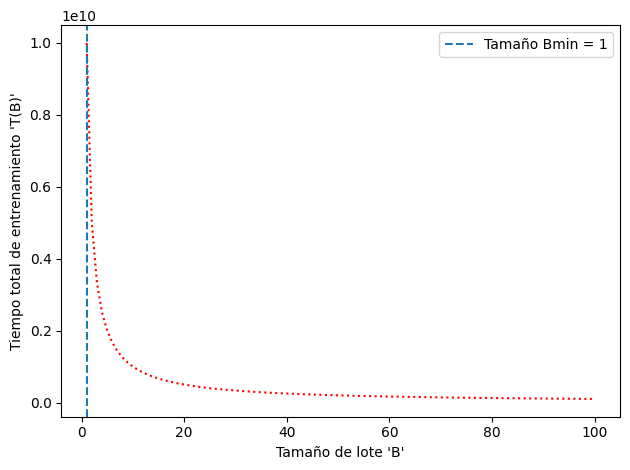

In [358]:
def plot_time_size_B(func):
  # B = 100
  B_values = np.linspace(1, 100, 100)

  out_values2 = []
  for b in B_values:
    out_values2.append(func.subs({B: int(b)}).evalf())


  plt.plot(B_values, out_values2, linestyle=':', color='red')
  plt.xlabel("Tamaño de lote 'B'")
  plt.ylabel("Tiempo total de entrenamiento 'T(B)'")
  plt.axvline(1, linestyle='--', label='Tamaño Bmin = 1')
  plt.tight_layout()
  plt.legend()
  plt.show()

plot_time_size_B(TB2_eval)

Optimización del lote

In [359]:
# Primera derivada
TB_prime = sp.simplify(sp.diff(TB, B))
TB_prime

2*B*c - N_total*t_0/B**2

In [360]:
# Para Despejar B cuando TB_prime = 0
TB_prime_at0 = sp.Eq(TB_prime, 0)
# cambiar signos
TB_prime_at0 = sp.Eq(-1 * TB_prime_at0.lhs, -1 * TB_prime_at0.rhs)
# Sumar 2Bc a cada lado
s1 = 2 * B * c
TB_prime_at0 = sp.Eq(TB_prime_at0.lhs + s1, TB_prime_at0.rhs + s1)
# Multiplicar cada lado por B^2
TB_prime_at0 = sp.Eq(TB_prime_at0.lhs * B**2, TB_prime_at0.rhs * B**2)
# Dividir ambos lados por 2*c
TB_prime_at0 = sp.Eq(TB_prime_at0.lhs / (2*c), TB_prime_at0.rhs / (2*c))
# Elevar 1/3 cada lado para remover raiz cubica de B
pow_third = sp.nsimplify(1/3)
TB_prime_at0  = sp.Eq(TB_prime_at0.lhs**(pow_third), (TB_prime_at0.rhs**(pow_third)))
# Simplificar
TB_prime_at0 = sp.simplify(TB_prime_at0)
TB_prime_at0

Eq((B**3)**(1/3), 2**(2/3)*(N_total*t_0/c)**(1/3)/2)

# Calcular el tamaño del lote para cada dataset

In [361]:
def tamanio_lote(n_total, t_mean, c_value, TB_prime_at0, TB2_eval):
  B_optimo = TB_prime_at0.subs({N_total: n_total, t0: t_mean, c: c_value})
  B_optimo = sp.solve(B_optimo, B)
  print(f"Para un dataset pequeño con condiciones: Ntotal = {int(n_total):,} ejemplos, t0 = {t_mean} segundos y constante computacional = {c_value} \n el tamaño del Lote óptimo sería B = {int(B_optimo[0])} ejemplos por lote")
  plot_time_size_B(TB2_eval)



Dataset pequeño

Para un dataset pequeño con condiciones: Ntotal = 100,000 ejemplos, t0 = 0.01 segundos y constante computacional = 0.01 
 el tamaño del Lote óptimo sería B = 36 ejemplos por lote


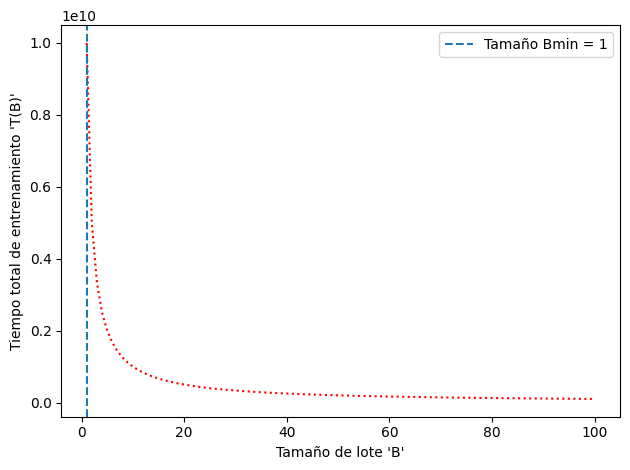

In [362]:
n_total = 10e4 # 10,000 ejemplos
t_mean = 0.01 # 10ms
c_value = 10e-3 # constante computacional CPU
tamanio_lote(n_total, t_mean, c_value, TB_prime_at0, TB2_eval)

Dataset mediano

Para un dataset pequeño con condiciones: Ntotal = 1,000,000 ejemplos, t0 = 0.1 segundos y constante computacional = 1e-05 
 el tamaño del Lote óptimo sería B = 1709 ejemplos por lote


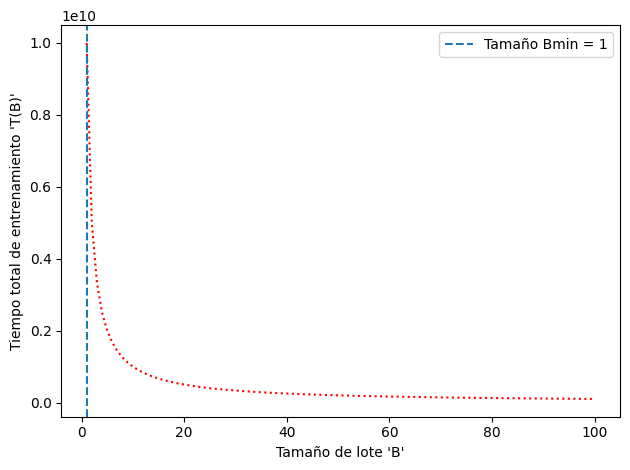

In [363]:
n_total = 1e6 # 1,000,000 ejemplos
t_mean = 0.1 # 100ms
c_value = 10e-6 # constante computacional GPU
tamanio_lote(n_total, t_mean, c_value, TB_prime_at0, TB2_eval)

Dataset grande

Para un dataset pequeño con condiciones: Ntotal = 100,000,000 ejemplos, t0 = 10 segundos y constante computacional = 1e-05 
 el tamaño del Lote óptimo sería B = 36840 ejemplos por lote


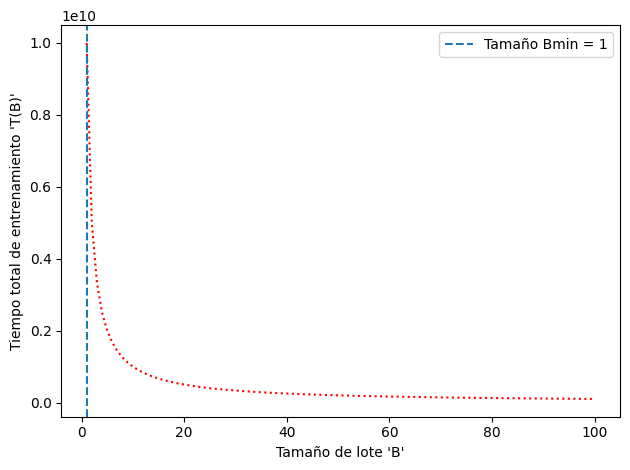

In [364]:
n_total = 1e8 # 100,000,000 ejemplos
t_mean = 10 # 10s
c_value = 10e-6 # constante computacional GPU
tamanio_lote(n_total, t_mean, c_value, TB_prime_at0, TB2_eval)